In [4]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
from resonator import Model_fit

In [5]:
from scipy.optimize import curve_fit

In [6]:
import os

In [21]:
def resonator_fit_from_dir(dirname,fit=True):
    header = "D:/K_sunada/database/"
    dd = datadict_from_hdf5(header+dirname+"/data")
    s11 = dd['s21']['values']
    f = dd['frequency']['values'] * 1e-9
    if fit:
        result = Model_fit(f,s11)
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[0].plot(f, np.abs(result.init_fit), '--', label='initial fit', color='orange')
        ax[0].plot(f, np.abs(result.best_fit), '-', label='best fit', color='red')
        ax[0].legend()
        ax[1].plot(f, np.angle(s11), '.', color='k')
        ax[1].plot(f, np.angle(result.init_fit), '--', label='initial fit', color='orange')
        ax[1].plot(f, np.angle(result.best_fit), '-', label='best fit', color='red')
        ax[1].legend()

        return result
    else:
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[1].plot(f, np.angle(s11), '.', color='k')
        return f, s11, fig, ax

In [18]:
def fit_partial(ff,fs11,startf,stopf):
    id1,id2 = np.argmin(np.abs(ff-startf)),np.argmin(np.abs(ff-stopf))
    f = ff[id1:id2]
    s11 = fs11[id1:id2]
    result = Model_fit(f,s11)
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    ax[0].plot(f, np.abs(s11), '.', color='k')
    ax[0].plot(f, np.abs(result.init_fit), '--', label='initial fit', color='orange')
    ax[0].plot(f, np.abs(result.best_fit), '-', label='best fit', color='red')
    ax[0].legend()
    ax[1].plot(f, np.angle(s11), '.', color='k')
    ax[1].plot(f, np.angle(result.init_fit), '--', label='initial fit', color='orange')
    ax[1].plot(f, np.angle(result.best_fit), '-', label='best fit', color='red')
    ax[1].legend()

    return result

In [19]:
dirlist = os.listdir('../database/2023-06-08/')
dirlist

['2023-06-08T155400_3f30a899-cw_sparameter',
 '2023-06-08T155942_0b5c38bf-cw_sparameter',
 '2023-06-08T160048_326d848c-cw_sparameter',
 '2023-06-08T160129_4b41a975-cw_sparameter',
 '2023-06-08T160454_c558f3f5-cw_sparameter',
 '2023-06-08T161130_b1698fd3-cw_sparameter',
 '2023-06-08T161229_d4397624-cw_sparameter',
 '2023-06-08T161431_1cd446b9-cw_sparameter',
 '2023-06-08T161858_bc803753-cw_sparameter',
 '2023-06-08T162255_4942dd82-cw_sparameter',
 '2023-06-08T162412_77269f82-cw_sparameter',
 '2023-06-08T163210_942c5972-cw_sparameter',
 '2023-06-08T164814_d2f2b025-cw_sparameter',
 '2023-06-08T164947_0a851479-cw_sparameter',
 '2023-06-08T165154_563c543e-cw_sparameter',
 '2023-06-08T165554_e4ffc8c6-cw_sparameter',
 '2023-06-08T165709_11c12b76-cw_sparameter',
 '2023-06-08T165839_4729cf13-cw_sparameter',
 '2023-06-08T165950_71ea3253-cw_sparameter']

s21: (1501,)
  ⌙ frequency (Hz): (1501,)


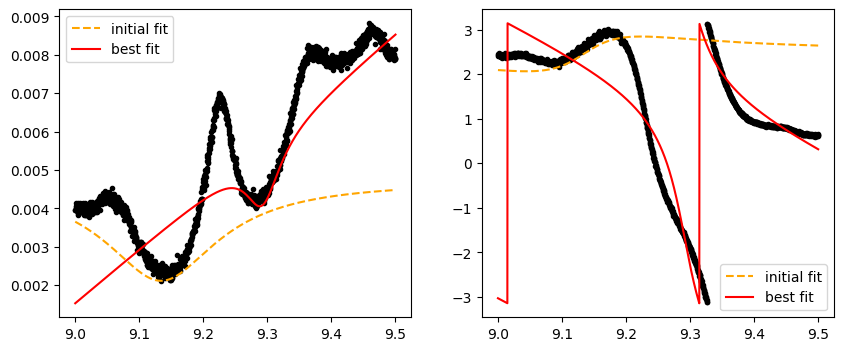

In [22]:
result = resonator_fit_from_dir('2023-06-08/'+dirlist[-1])
result